# Ejercicio 4: viajes con SUBE en el subte de CABA

Este notebook implementa el ejercicio 4 del trabajo practico usando la matriz OD publicada por el BID en el repositorio `EL-BID/Matriz-Origen-Destino-Transporte-Publico`. La idea es construir una probabilidad `P''(i->j)` basada en trayectorias observadas de usuarios SUBE en el subte y compararla contra los modelos previos sin peso, con demanda potencial y con demanda mas atraccion.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from analisis_viajes_sube_subte_caba import generate_outputs

BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / 'figures'

results = generate_outputs()
config = results['config']
diagnostics = results['diagnostics']
mapping_diagnostics = results['mapping_diagnostics']
model_summary = results['model_summary']
station_metrics = results['station_metrics']
top_pairs = results['top_pairs']
top_betweenness_sube = results['top_betweenness_sube']
top_gain_sube_vs_atraccion = results['top_gain_sube_vs_atraccion']
top_loss_sube_vs_atraccion = results['top_loss_sube_vs_atraccion']

## 1. Fuente y criterio de construccion de `P''`

La fuente externa es el repositorio del BID con resultados de matriz OD basados en datos SUBE. Para este ejercicio se usan tres tablas publicadas alli:

- `resultados/etapas.csv`,
- `data/paradas.csv`,
- `data/lineas_ramales.csv`.

El criterio adoptado es trabajar con las **etapas de subte** (`modo = SUB`) y no con los viajes multimodales completos. Eso hace que cada observacion cuente como una trayectoria realista dentro de la red de subte entre una parada de origen y una parada de destino imputada por la metodologia del BID.

Despues, cada parada SUBE se empalma contra la red local de 90 estaciones del proyecto. Con `Echeverria` ya incorporada en la linea B, el empalme entre paradas SUBE y estaciones de la red queda completo para las lineas analizadas.

In [2]:
config

,parametro,valor
0,bid_etapas_fuente,https://media.githubusercontent.com/media/EL-B...
1,bid_paradas_fuente,https://media.githubusercontent.com/media/EL-B...
2,bid_lineas_ramales_fuente,https://media.githubusercontent.com/media/EL-B...


In [3]:
diagnostics

,indicador,valor
0,bid_etapas_fuente,https://media.githubusercontent.com/media/EL-B...
1,bid_paradas_fuente,https://media.githubusercontent.com/media/EL-B...
2,bid_lineas_ramales_fuente,https://media.githubusercontent.com/media/EL-B...
3,bid_subte_stops_without_network_station,0
4,network_stations_without_bid_stop,0
5,subte_stages_total,1038034.0
6,subte_stages_complete_od,983259.0
7,subte_stages_mapped_to_network,976322.0
8,subte_stages_same_station_dropped,23792.0
9,subte_stages_used_in_pdd,952530.0


In [4]:
display(mapping_diagnostics['bid_stops_without_network_station'])
display(mapping_diagnostics['network_stations_without_bid_stop'])

,linea,nombre_estacion,estacion_canonica


,linea,estacion_red


Lectura rapida del empalme:

- la red local queda completamente cubierta por las paradas de subte del BID,
- no quedan sobrantes del lado BID despues del empalme,
- `P''` termina construido sobre etapas observadas con origen y destino completos, mapeadas a la misma red del resto del TP.

## 2. Pares OD mas frecuentes en SUBE

La tabla siguiente resume los pares estacion-estacion con mayor peso relativo en `P''`. Aca ya no hay una ley gravitatoria supuesta: son trayectorias recuperadas del dataset del BID y reexpresadas sobre la red del proyecto.

In [5]:
top_pairs.assign(probabilidad=lambda df: df['probabilidad'].round(4)).head(15)

,origen,linea_origen,destino,linea_destino,viajes_estimados,probabilidad
0,Retiro,C,Constitución,C,10101,0.0106
1,Constitución,C,Retiro,C,5561,0.0058
2,Constitución,C,Retiro,E,5549,0.0058
3,Congreso de Tucumán,D,Catedral,D,3377,0.0035
4,Lavalle,C,Constitución,C,3373,0.0035
5,Catedral,D,Congreso de Tucumán,D,3112,0.0033
6,Florida,B,Federico Lacroze,B,2614,0.0027
7,Leandro N. Alem,B,Federico Lacroze,B,2605,0.0027
8,Plaza de Mayo,A,Once,H,2427,0.0025
9,Constitución,C,Lavalle,C,2415,0.0025


Los pares mas frecuentes ya dejan una pista importante: aparecen muy fuerte las terminales y corredores largos realmente usados, como `Retiro-Constitucion`, `Congreso de Tucuman-Catedral` o viajes largos de la linea B. Eso adelanta que `P''` no se va a parecer ni al escenario uniforme ni al de pura demanda residencial.

## 3. Comparacion de tiempos medios

La tabla compara los cuatro escenarios:

- sin peso,
- demanda potencial `P`,
- demanda mas atraccion `P'`,
- SUBE realista `P''`.

La lectura esperable es que el escenario realista reduzca la distancia media respecto del caso uniforme, pero no tanto como el modelo puramente gravitatorio, porque los viajes observados siguen sosteniendo recorridos largos y transbordos fuertes en corredores centrales.

In [6]:
model_summary.assign(
    tiempo_medio=lambda df: df['tiempo_medio'].round(2),
    delta_vs_sin_peso_pct=lambda df: df['delta_vs_sin_peso_pct'].round(2),
)

,escenario,tiempo_medio,delta_vs_sin_peso_pct
0,Sin peso,23.51,0.00
1,Demanda potencial,15.99,-32.01
2,Demanda y atraccion,15.88,-32.45
3,SUBE realista,20.83,-11.42


## 4. Betweenness bajo `P''`

Con `P''` la betweenness ya no responde a una distribucion hipotetica de masas sino a trayectorias reconstruidas desde SUBE. El mapa y la tabla ayudan a ver que estaciones ganan protagonismo cuando se usan flujos observados.

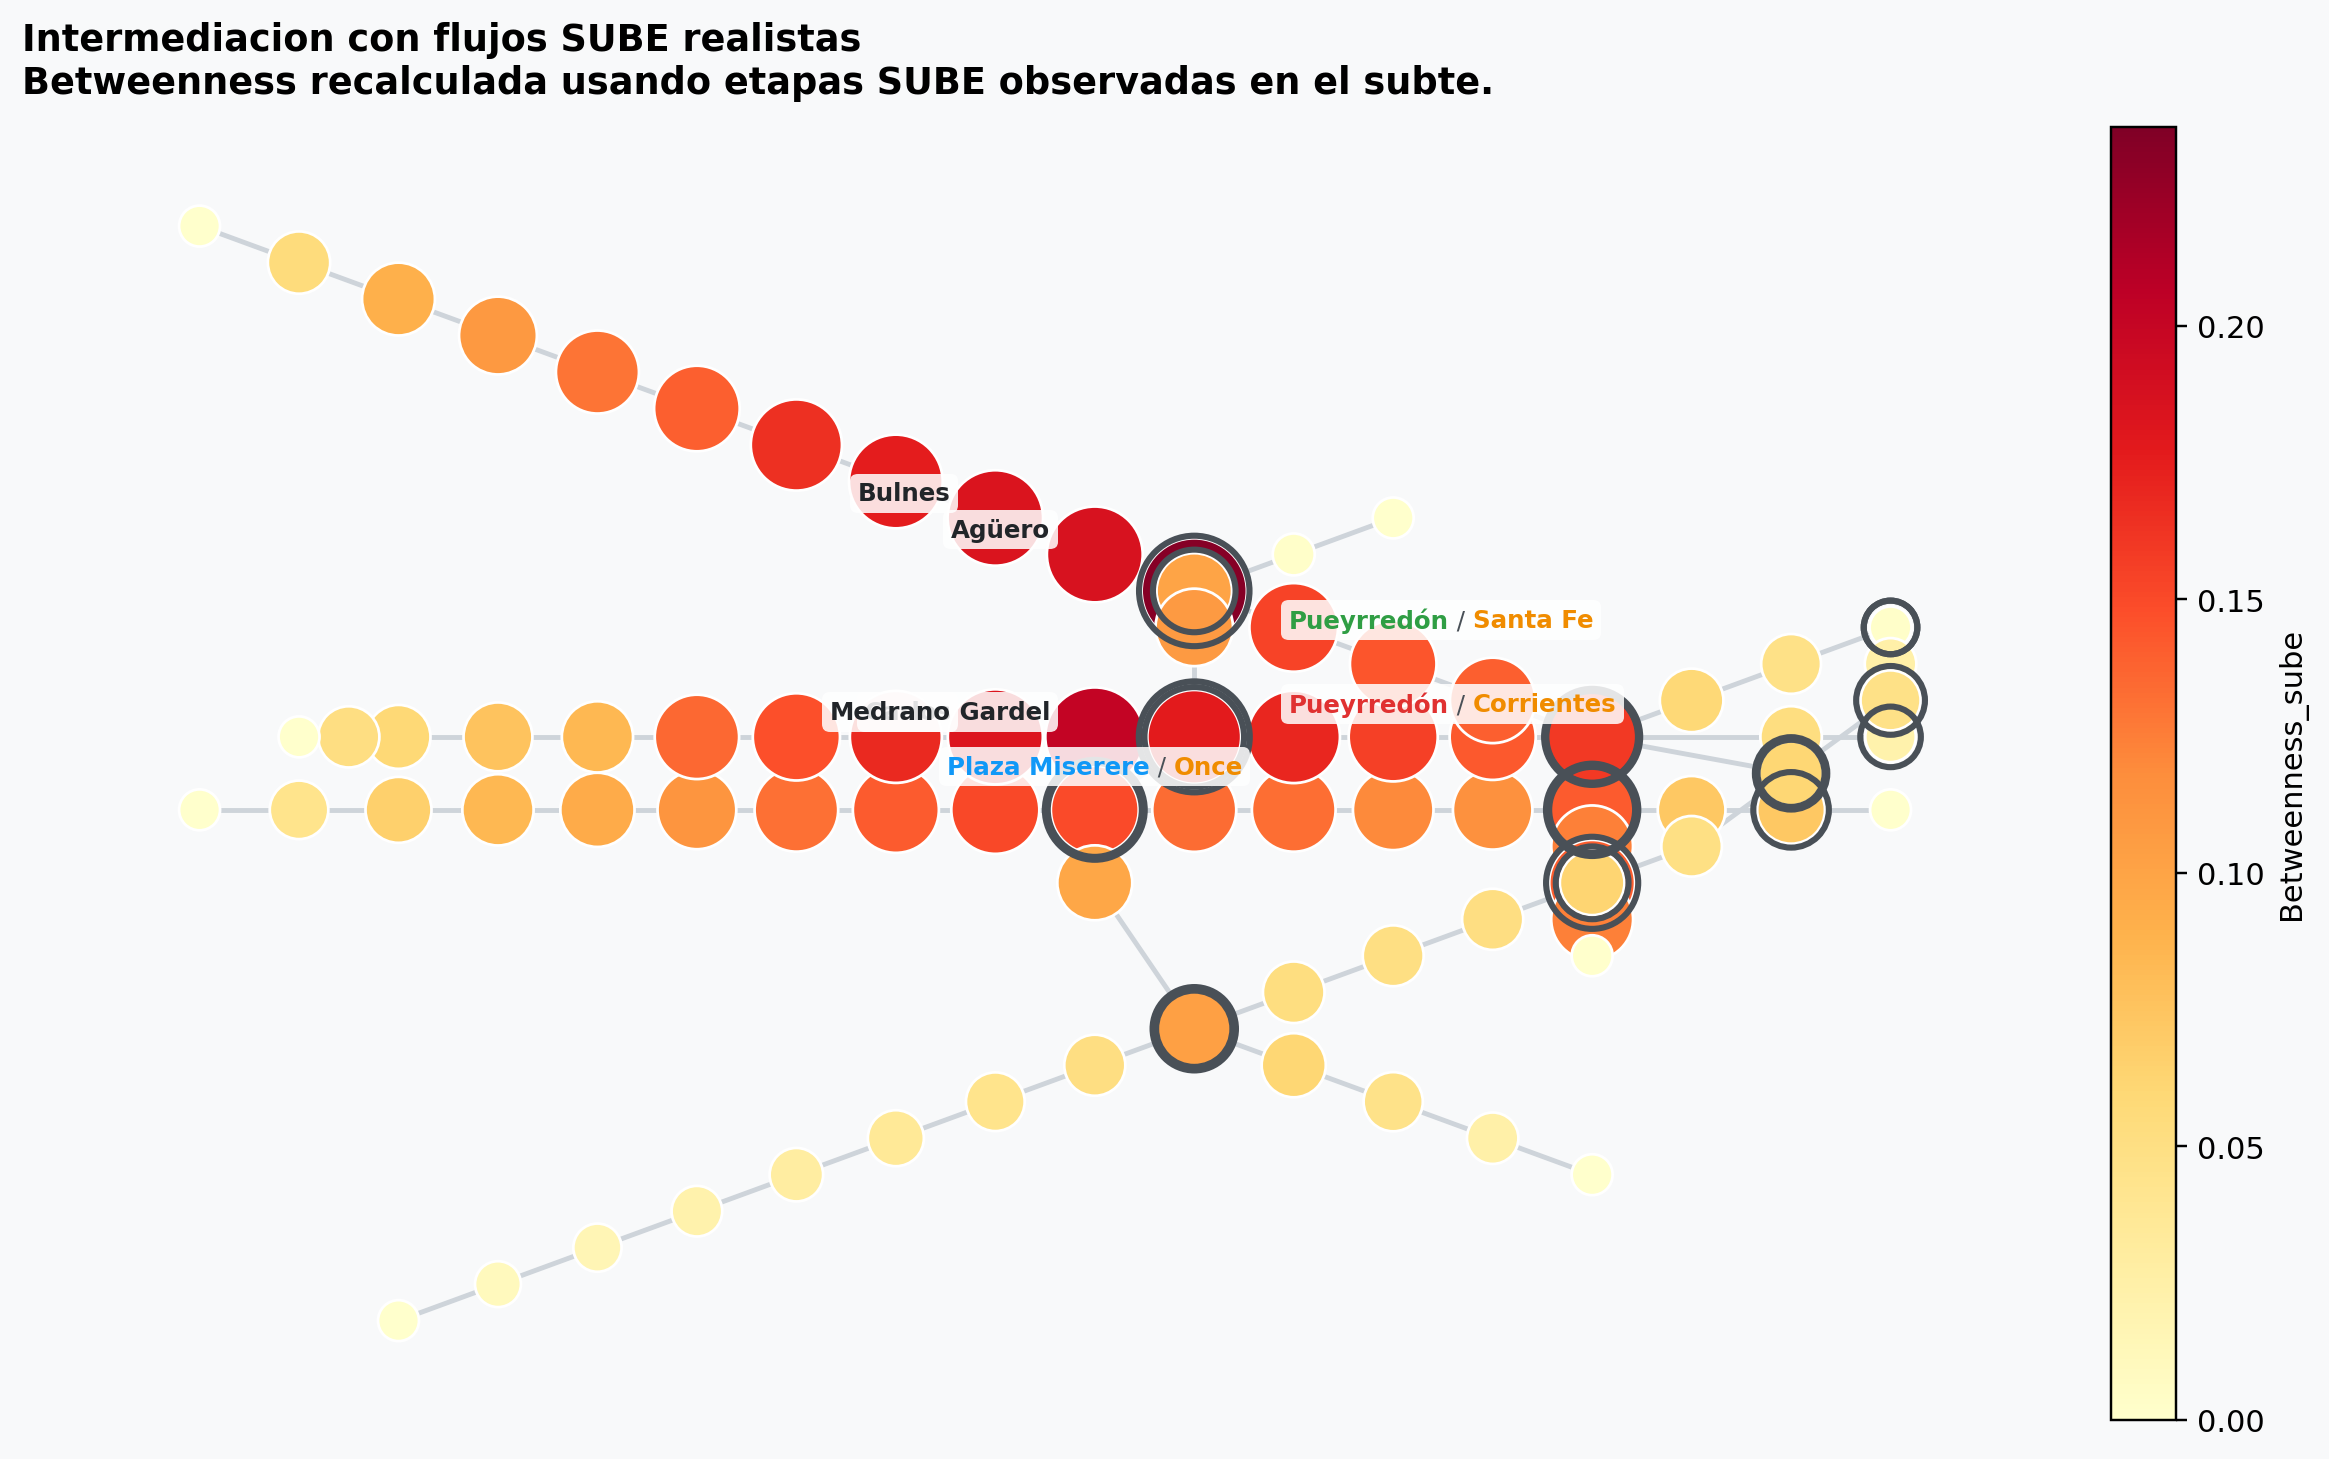

,estacion,linea,betweenness_atraccion,betweenness_sube,cambio_sube_vs_atraccion
4,Pueyrredón,B,0.1588,0.2363,0.0776
9,Pueyrredón,D,0.2156,0.2333,0.0177
19,Carlos Gardel,B,0.0929,0.2013,0.1083
30,Agüero,D,0.1548,0.1863,0.0315
42,Bulnes,D,0.1326,0.1846,0.0520
35,Medrano,B,0.0767,0.1825,0.1058
11,Plaza Miserere,A,0.1593,0.1780,0.0187
0,Corrientes,H,0.2588,0.1767,-0.0821
53,Scalabrini Ortiz,D,0.1148,0.1763,0.0616
17,Pasteur,B,0.0755,0.1703,0.0948


In [7]:
display(Image(filename=str(FIGURES_DIR / 'betweenness_sube_realista.png')))
top_betweenness_sube.assign(
    betweenness_atraccion=lambda df: df['betweenness_atraccion'].round(4),
    betweenness_sube=lambda df: df['betweenness_sube'].round(4),
    cambio_sube_vs_atraccion=lambda df: df['cambio_sube_vs_atraccion'].round(4),
)

In [8]:
display(
    top_gain_sube_vs_atraccion.assign(
        betweenness_atraccion=lambda df: df['betweenness_atraccion'].round(4),
        betweenness_sube=lambda df: df['betweenness_sube'].round(4),
        cambio_sube_vs_atraccion=lambda df: df['cambio_sube_vs_atraccion'].round(4),
    )
)

display(
    top_loss_sube_vs_atraccion.assign(
        betweenness_atraccion=lambda df: df['betweenness_atraccion'].round(4),
        betweenness_sube=lambda df: df['betweenness_sube'].round(4),
        cambio_sube_vs_atraccion=lambda df: df['cambio_sube_vs_atraccion'].round(4),
    )
)

,estacion,linea,betweenness_atraccion,betweenness_sube,cambio_sube_vs_atraccion
56,San Juan,C,0.0109,0.1246,0.1137
19,Carlos Gardel,B,0.0929,0.2013,0.1083
49,Ángel Gallardo,B,0.0626,0.1685,0.1059
35,Medrano,B,0.0767,0.1825,0.1058
33,Independencia,C,0.0393,0.1412,0.1019
57,Malabia,B,0.0457,0.1470,0.1014
63,Dorrego,B,0.0391,0.1350,0.0959
17,Pasteur,B,0.0755,0.1703,0.0948
21,Callao,B,0.0626,0.1552,0.0926
25,Moreno,C,0.0405,0.1241,0.0836


,estacion,linea,betweenness_atraccion,betweenness_sube,cambio_sube_vs_atraccion
0,Corrientes,H,0.2588,0.1767,-0.0821
2,Once,H,0.2281,0.1500,-0.0781
7,Santa Fe,H,0.1615,0.0998,-0.0617
12,Córdoba,H,0.1649,0.1074,-0.0576
15,Jujuy,E,0.1023,0.0748,-0.0275
14,Catedral,D,0.0587,0.0421,-0.0166
10,Venezuela,H,0.1139,0.0977,-0.0162
6,Humberto 1º,H,0.1142,0.1030,-0.0112
48,Las Heras,H,0.0088,0.0021,-0.0067
5,Bolívar,E,0.0640,0.0605,-0.0035


## 5. Cierre del ejercicio 4

El resultado central del ejercicio 4 es que `P''` aporta una capa empirica que los modelos `P` y `P'` no podian reconstruir del todo. En particular:

- mantiene viajes largos y terminales muy activos,
- reposiciona estaciones de las lineas B y D como puentes fuertes,
- baja el tiempo medio respecto del caso uniforme, pero bastante menos que los modelos gravitatorios,
- muestra que demanda residencial y atraccion urbana son utiles, aunque insuficientes para reproducir por si solas los patrones reales de uso del subte.

En otras palabras, `P''` sirve como benchmark empirico para evaluar cuan realistas son `P` y `P'` antes de pasar al ejercicio 5 sobre el impacto de nuevas lineas.